# 03 — Regresja logistyczna: predykcja choroby serca

> Jeden z 5 notebooków porównania algorytmów. Ten sam dataset (Heart Disease UCI, 303 próbki, 13 cech) i ten sam pipeline co pozostałe — zmienia się tylko algorytm.

**Regresja logistyczna** to liniowy model klasyfikacyjny: modeluje logarytm szansy (log-odds) przynależności do klasy jako liniową kombinację cech przepuszczoną przez funkcję sigmoidalną. Zalety: prostota, szybkość i **interpretowalne współczynniki** (znak i wielkość wagi = kierunek i siła wpływu cechy). Wymaga skalowania cech — pipeline projektu zapewnia je przez `StandardScaler`.

**Metryki (jedyne 4 w projekcie):** Accuracy, F1-Score, ROC-AUC, MCC.

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

# katalog główny repo = ten, w którym leży data/heart.csv (działa z notebooks/ i z roota)
_root = os.getcwd()
while not os.path.exists(os.path.join(_root, 'data', 'heart.csv')) and _root != os.path.dirname(_root):
    _root = os.path.dirname(_root)
os.chdir(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone

from src.preprocessing import load_data, preprocess, split_and_scale
from src.evaluation import plot_confusion_matrix, plot_roc_curve, plot_learning_curve
from src.model import cross_validate
from src import algorithms as alg

os.makedirs('plots', exist_ok=True)
os.makedirs('results', exist_ok=True)
RANDOM_STATE = 42
DATA_PATH = 'data/heart.csv'

In [2]:
# --- wybór algorytmu z rejestru src/algorithms.py (jedno źródło prawdy) ---
NAME = 'Regresja logistyczna'
CFG  = alg.ALGORITHMS[NAME]
SLUG = CFG['slug']
build, grid = CFG['build'], CFG['grid']
print(f'Algorytm: {NAME}  |  slug: {SLUG}')

Algorytm: Regresja logistyczna  |  slug: logistic_regression


## 1. Dane

303 pacjentów, 13 cech, target binarny (0 = brak, 1 = choroba). Braki w `ca`/`thal` (jako `?`) → imputacja medianą. Pełna EDA: `notebooks/01_eda.ipynb`.

In [3]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Wymiary: {df_raw.shape}')
df_raw.head()

Wymiary: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# przypomnienie balansu klas (pełna EDA: notebooks/01_eda.ipynb)
X, y = preprocess(load_data(DATA_PATH))
vc = y.value_counts().sort_index()
print(f'Brak choroby (0): {vc[0]}  |  Choroba (1): {vc[1]}  |  udział klasy 1: {vc[1] / vc.sum():.1%}')
print(f'Cechy ({X.shape[1]}): {list(X.columns)}')

Brak choroby (0): 164  |  Choroba (1): 139  |  udział klasy 1: 45.9%
Cechy (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## 2. Preprocessing

Czyszczenie `?`→mediana, binaryzacja targetu, split **80/20 stratified** + `StandardScaler`. **Identyczny split we wszystkich notebookach** (warunek sprawiedliwego porównania) — funkcje z `src/preprocessing.py`.

In [5]:
X, y = preprocess(load_data(DATA_PATH))
X_train, X_test, X_train_s, X_test_s, y_train, y_test, scaler = split_and_scale(X, y)
print(f'Train: {X_train_s.shape[0]} próbek  |  Test: {X_test_s.shape[0]} próbek  |  Cechy: {X_train_s.shape[1]}')
print(f'Target train: {y_train.value_counts().to_dict()}  |  test: {y_test.value_counts().to_dict()}')

Train: 242 próbek  |  Test: 61 próbek  |  Cechy: 13
Target train: {0: 131, 1: 111}  |  test: {0: 33, 1: 28}


## 3. Model bazowy

Model z ustawieniami domyślnymi jako punkt odniesienia przed tuningiem. Mierzymy też czas trenowania.

In [6]:
baseline = build()
baseline, fit_time_baseline = alg.timed_fit(baseline, X_train_s, y_train)
metrics_baseline = alg.evaluate(baseline, X_test_s, y_test)
alg.print_metrics(metrics_baseline, title=f'{NAME} — baseline (test)')
print(f'\nCzas trenowania baseline: {fit_time_baseline * 1000:.1f} ms')

=== Regresja logistyczna — baseline (test) ===
  Accuracy : 0.8689
  F1-Score : 0.8667
  ROC-AUC  : 0.9513
  MCC      : 0.7451

Czas trenowania baseline: 7.5 ms


## 4. Tuning hiperparametrów

`GridSearchCV`, 5-fold CV, `scoring='f1'`. Siatka zdefiniowana w `src/algorithms.py`.

In [7]:
import functools, operator
grid_size = functools.reduce(operator.mul, [len(v) for v in grid.values()], 1)
print(f'Siatka hiperparametrów: {grid}')
print(f'Kombinacji: {grid_size}  |  Fitów (5-fold CV): {grid_size * 5}\n')

best_model, gs = alg.tune(build(), grid, X_train_s, y_train, scoring='f1', cv=5)
print('Najlepsze parametry:')
for k, v in gs.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nCV F1 (best): {gs.best_score_:.4f}')

Siatka hiperparametrów: {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear'], 'class_weight': [None, 'balanced']}
Kombinacji: 20  |  Fitów (5-fold CV): 100



Najlepsze parametry:
  C: 0.1
  class_weight: None
  penalty: l2
  solver: lbfgs

CV F1 (best): 0.8034


## 5. Ewaluacja po tuningu

Cztery metryki na zbiorze testowym + walidacja krzyżowa (czy model generalizuje).

In [8]:
tuned = best_model
metrics_tuned = alg.evaluate(tuned, X_test_s, y_test)
alg.print_metrics(metrics_tuned, title=f'{NAME} — po tuningu (test)')

=== Regresja logistyczna — po tuningu (test) ===
  Accuracy : 0.8525
  F1-Score : 0.8475
  ROC-AUC  : 0.9578
  MCC      : 0.7087


In [9]:
cv_results = cross_validate(tuned, X_train_s, y_train, cv=5)
print('=== 5-fold Cross-Validation (zbiór treningowy) ===')
for metric, scores in cv_results.items():
    print(f'  {metric:9s}: {scores.mean():.4f} ± {scores.std():.4f}')

=== 5-fold Cross-Validation (zbiór treningowy) ===
  f1       : 0.8034 ± 0.0581
  accuracy : 0.8263 ± 0.0500
  roc_auc  : 0.8914 ± 0.0456


## 6. Wizualizacje

Macierz pomyłek, krzywa ROC, ważność cech i krzywa uczenia. Interpretacja: **współczynniki** modelu (`coef_`). Kolor słupka = znak wpływu na ryzyko choroby.

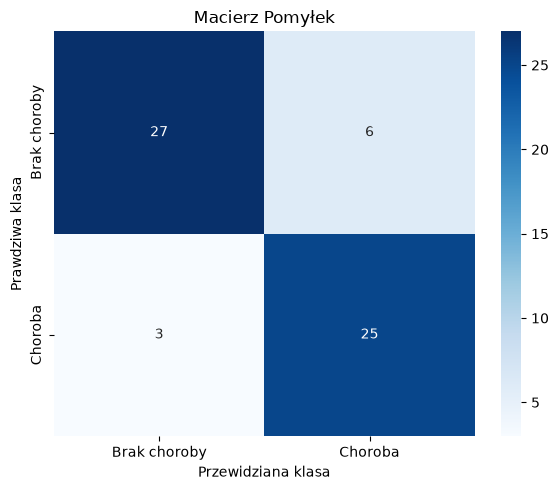

In [10]:
plot_confusion_matrix(tuned, X_test_s, y_test, save_path=f'plots/{SLUG}_confusion_matrix.png')

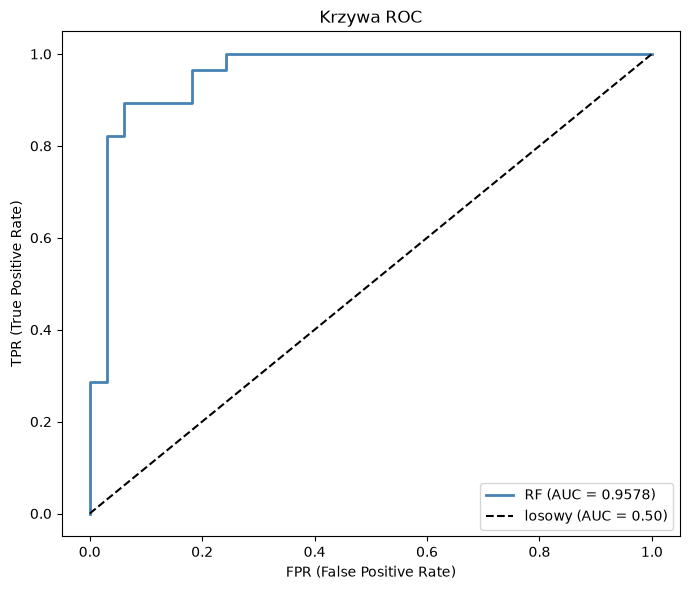

In [11]:
plot_roc_curve(tuned, X_test_s, y_test, save_path=f'plots/{SLUG}_roc_curve.png')

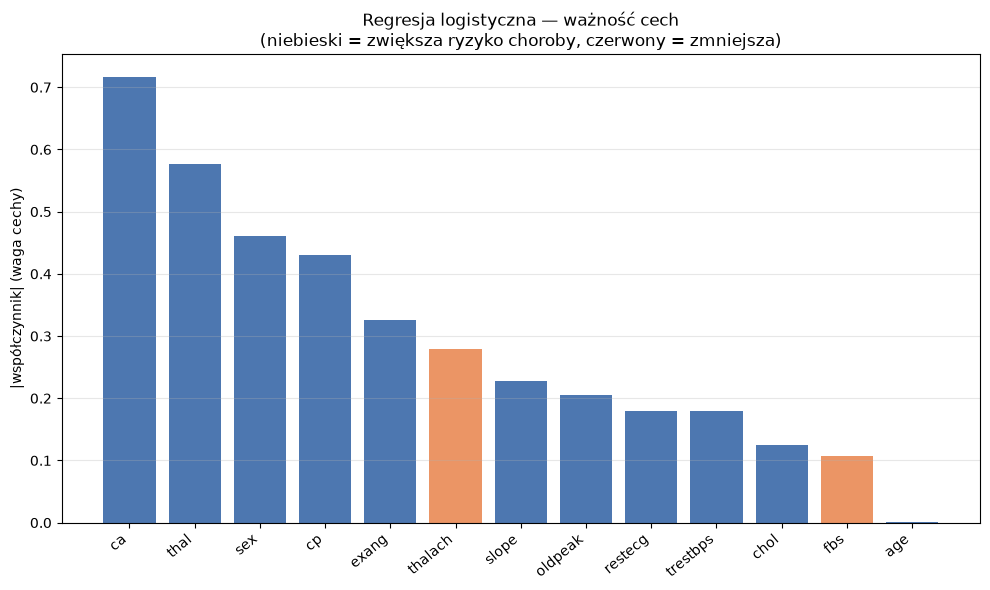

In [12]:
alg.plot_importance(tuned, X.columns, X_test_s, y_test,
                    title=f'{NAME} — ważność cech',
                    save_path=f'plots/{SLUG}_importance.png')

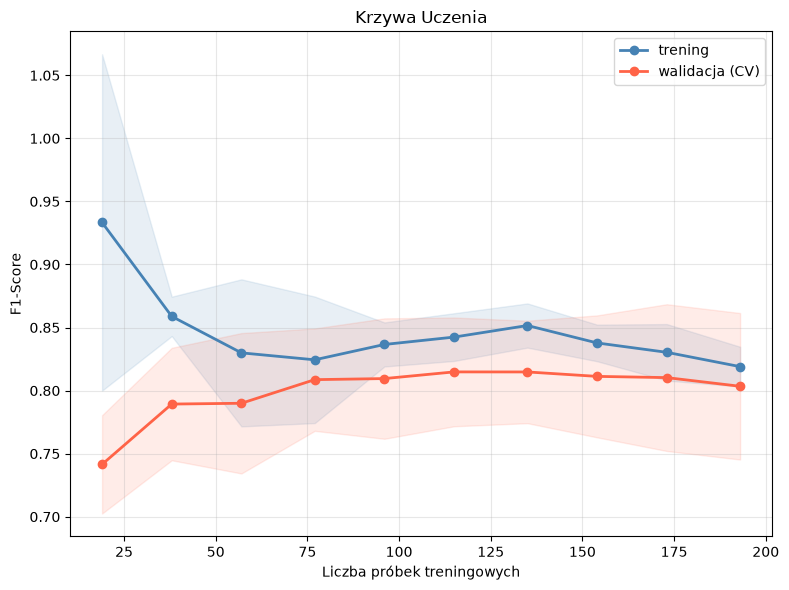

In [13]:
plot_learning_curve(tuned, X_train_s, y_train, save_path=f'plots/{SLUG}_learning_curve.png')

## 7. Porównanie: baseline vs po tuningu

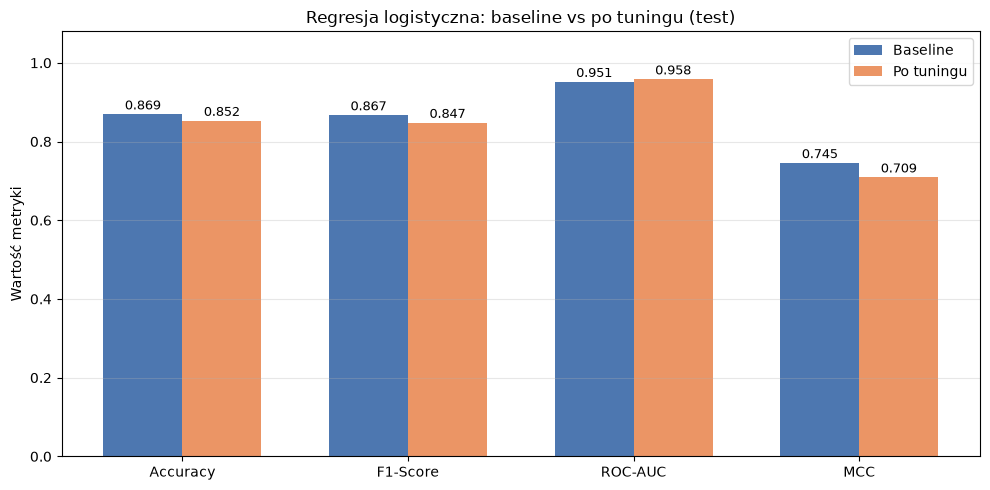

,Metryka,Baseline,Po tuningu,Delta
0,Accuracy,0.8689,0.8525,-0.0164
1,F1-Score,0.8667,0.8475,-0.0192
2,ROC-AUC,0.9513,0.9578,+0.0065
3,MCC,0.7451,0.7087,-0.0364


In [14]:
metric_names = ['accuracy', 'f1', 'roc_auc', 'mcc']
labels_pl = ['Accuracy', 'F1-Score', 'ROC-AUC', 'MCC']
vb = [metrics_baseline[m] for m in metric_names]
vt = [metrics_tuned[m] for m in metric_names]

x = np.arange(len(metric_names)); w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w / 2, vb, w, label='Baseline', color='#2E5FA3', alpha=0.85)
b2 = ax.bar(x + w / 2, vt, w, label='Po tuningu', color='#E8834A', alpha=0.85)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(labels_pl); ax.set_ylim(0, 1.08)
ax.set_ylabel('Wartość metryki'); ax.set_title(f'{NAME}: baseline vs po tuningu (test)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'plots/{SLUG}_baseline_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

summary = pd.DataFrame({'Metryka': labels_pl,
                        'Baseline': [f'{v:.4f}' for v in vb],
                        'Po tuningu': [f'{v:.4f}' for v in vt],
                        'Delta': [f'{(t - b):+.4f}' for b, t in zip(vb, vt)]})
summary

## 8. Zapis wyników

Metryki, najlepsze parametry i czasy → `results/<slug>.json`. Używane przez notebook zbiorczy `07_summary_comparison.ipynb`.

In [15]:
# osobny pomiar czasu trenowania modelu po tuningu + czasu predykcji
_, fit_time_tuned = alg.timed_fit(clone(tuned), X_train_s, y_train)
predict_time = alg.timed_predict(tuned, X_test_s, repeat=10)

results = {
    'name': NAME, 'slug': SLUG,
    'baseline': metrics_baseline,
    'tuned': metrics_tuned,
    'best_params': gs.best_params_,
    'cv_f1_best': float(gs.best_score_),
    'grid_size': int(grid_size),
    'fit_time_baseline': float(fit_time_baseline),
    'fit_time_tuned': float(fit_time_tuned),
    'predict_time': float(predict_time),
    'n_train': int(X_train_s.shape[0]),
    'n_test': int(X_test_s.shape[0]),
    'n_features': int(X_train_s.shape[1]),
    'cv': {m: {'mean': float(s.mean()), 'std': float(s.std())} for m, s in cv_results.items()},
}
path = alg.save_results(SLUG, results)
print(f'Zapisano wyniki do: {path}')
pd.Series(results['tuned']).round(4)

Zapisano wyniki do: results/logistic_regression.json


accuracy    0.8525
f1          0.8475
roc_auc     0.9578
mcc         0.7087
dtype: float64